# MMSE 없는 CN · MCI · DEM — v2
## 피험자 단위 ablation · nested CV · AUC/recall 중심 탐색

**제작 시점(2026-09-22): 특징 추출과 학습 없는 준비 검사는 완료했습니다. 분류기 학습과 v2 성능 측정은 사용자에게 맡겼으며 수행하지 않았습니다.**

원본은 보존했습니다. 전체 분석 및 사용법은 [ANALYSIS_v1_AND_V2.md](ANALYSIS_v1_AND_V2.md)에 있습니다. 이 노트북은 같은 폴더의 `lifelog_v2/` 패키지를 사용합니다.

- 유지 조건: **피험자 단위 분할, MMSE 미포함**. MMSE 원천/라벨 파일은 읽지 않습니다.
- 지표: **macro one-vs-rest ROC-AUC ≥ 0.8, macro recall ≥ 0.8**. 클래스별 recall도 별도 보고합니다.
- v2의 non-nested 제한은 해제된 것으로 적용하여, 내부 모델 선택과 분리된 **중첩 CV**를 추가합니다.
- 기존 공식 Validation은 v1에서 이미 결과를 본 데이터입니다. v2에서 설정 선택에 쓰지 않으며, 새 미사용 외부 검증으로 부르지 않습니다.

## 1. 기존 실행 결과

| 평가 | ROC-AUC | Macro recall | Macro F1 | Accuracy | CN recall | MCI recall | DEM recall |
|---|---:|---:|---:|---:|---:|---:|---:|
| 개발 OOF, 141명 | 0.559757 | 0.486821 | 0.493644 | 0.531915 | 0.611765 | 0.404255 | 0.444444 |
| 공식 Validation, 33명 | 0.595454 | 0.427350 | 0.498551 | 0.545455 | 0.615385 | 0.000000 | 0.666667 |

기준에 미달하며 특히 Validation의 MCI 4명이 모두 CN으로 분류되었습니다. DEM recall 0.667은 3명 중 2명이므로 정밀한 성능 추정이 아닙니다. Validation macro AUC의 저장된 95% bootstrap 구간은 0.492–0.705, macro recall은 0.218–0.590입니다.

학습 데이터의 독립 표본 수는 141명(CN 85/MCI 47/DEM 9)입니다. 기존의 일별 기록 9,705개가 독립 표본 수를 늘려 주지는 않습니다. 기존은 macro-F1에 맞춰 선택되었고 동일 OOF를 튜닝에 재사용했습니다.

## 2. 환경과 실험 설정

현재 프로젝트의 `.venv`를 커널로 선택하세요. 필요한 버전은 `requirements_v2.txt`에 기록되어 있습니다. 다른 환경에서 필요한 경우 다음 명령을 별도로 실행하세요.

```bash
python -m pip install -r requirements_v2.txt
```

기본값은 최종 Optuna 80 trial, 바깥 fold마다 20 trial, 27개 고정 ablation, 최종 선택 모델 3 seeds입니다. 단일 시드에서 기본 1,240개 후보×fold 평가에 추가 시드·최종 학습이 더해집니다. 실제 시간은 측정하지 않았습니다. CPU 4 threads이며 GPU는 사용하지 않습니다.

In [1]:
from pathlib import Path
import os, sys, json
from dataclasses import asdict
import pandas as pd
from IPython.display import display, Markdown, Image

PROJECT_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'lifelog_v2').is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('lifelog_v2 폴더가 있는 프로젝트에서 노트북을 실행하세요.')
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from lifelog_v2 import feature_engineering as fe
from lifelog_v2.data import load_dataset
from lifelog_v2.experiments import Config, ablation_specs, subject_folds, fold_table, run_experiment, versions
from lifelog_v2.check_preparation import check_preparation

DATA_ROOT = None  # None이면 프로젝트의 Data 경로 자동 탐지
CFG = Config(
    threads=4,
    development_folds=5,
    outer_folds=5,
    inner_folds=3,
    n_trials=80,
    nested_trials=20,
    run_nested=True,
    final_seeds=(2026, 2037, 2048),
    output_dir='results_v2/run_full',
    cache_dir='results_v2/cache',
    bootstrap_repeats=2000,
)
display(pd.Series(asdict(CFG), name='configuration'))
display(pd.Series(versions(), name='package_version'))

/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


seed                                   2026
threads                                   4
development_folds                         5
outer_folds                               5
inner_folds                               3
n_trials                                 80
nested_trials                            20
run_nested                             True
final_seeds              (2026, 2037, 2048)
max_ensemble_members                      4
ensemble_steps                            8
tune_decisions                         True
bootstrap_repeats                      2000
threshold                               0.8
cache_dir                  results_v2/cache
output_dir              results_v2/run_full
Name: configuration, dtype: object

numpy            2.5.3
pandas           3.0.6
scipy           1.18.1
scikit-learn     1.9.1
catboost        1.2.10
optuna           5.0.0
joblib           1.6.0
Name: package_version, dtype: str

## 3. 이미 추출한 특징과 입력 확인 — 분류기 학습 없음

| 표현 | Training 행 | Validation 행 | 특징 |
|---|---:|---:|---:|
| 개인 요약 v1 | 141 | 33 | 670 |
| 확장 개인 요약 | 141 | 33 | 1,333 |
| 14일 구간 | 784 | 196 | 1,333 |
| 28일 구간 | 449 | 110 | 1,333 |

추가된 특징은 개인 내부 평균·표준편차·MAD·변동계수·주말/평일 차이 및 시간대별 MET 평균·표준편차입니다. 날짜는 구간 구분과 개인 내부 계산에만 사용합니다. 진단은 정답에만, ID는 연결·분할에만 사용합니다.

구간 수와 무관하게 평가는 **Training 141명 / Validation 33명**입니다. 같은 사람의 모든 구간은 같은 fold에 배정합니다. 학습 가중치는 피험자의 구간 수와 클래스별 사람 수를 고려합니다.

캐시 키에 원천 파일·허용 라벨 파일·특징 코드의 SHA256을 넣었습니다. 동일하면 재사용하고, 입력이나 특징 코드가 바뀌면 재추출합니다. 이 셀에서 Validation을 읽는 것은 입력 구조·중복 확인이며 모델 선택 지표를 계산하지 않습니다.

In [2]:
ROOT, PATHS = fe.resolve_paths(DATA_ROOT)
training = load_dataset(PATHS['train'], CFG.cache_dir)
validation = load_dataset(PATHS['val'], CFG.cache_dir)
assert not set(training.subjects).intersection(validation.subjects)

rows = []
for split, dataset in [('Training', training), ('Validation', validation)]:
    for name, rep in dataset.representations.items():
        rows.append(dict(split=split, representation=name, subjects=len(dataset.labels),
                         rows=len(rep.X), features=rep.X.shape[1]))
display(pd.DataFrame(rows))
display(pd.DataFrame({
    'Training': training.labels.value_counts().rename(index=dict(enumerate(fe.CLASS_NAMES))),
    'Validation': validation.labels.value_counts().rename(index=dict(enumerate(fe.CLASS_NAMES)))
}).reindex(fe.CLASS_NAMES))
display(pd.DataFrame(training.audit))
display(pd.DataFrame(validation.audit))

Using feature cache: features_ace307489ac40f60e694f469333865e85f633185d25a307c89d656cb2be27f30.joblib
Using feature cache: features_2148c23335900b8a8a9da91a05df46d161e3fec7f577d20e061366499d3eac66.joblib


,split,representation,subjects,rows,features
0,Training,subject_v1,141,141,670
1,Training,subject_plus,141,141,1333
2,Training,window14,141,784,1333
3,Training,window28,141,449,1333
4,Validation,subject_v1,33,33,670
5,Validation,subject_plus,33,33,1333
6,Validation,window14,33,196,1333
7,Validation,window28,33,110,1333


,Training,Validation
label,,
CN,85,26
MCI,47,4
DEM,9,3


,split,modality,input_rows,bad_dates,duplicate_subject_dates,kept_rows,subjects,representation,rows,full_period_fallback_subjects
0,requested_split,activity,9705.0,0.0,0.0,9705.0,141,NaN,NaN,NaN
1,requested_split,sleep,9705.0,0.0,11.0,9694.0,141,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,141,window14,784.0,0.0
3,NaN,NaN,NaN,NaN,NaN,NaN,141,window28,449.0,0.0


,split,modality,input_rows,bad_dates,duplicate_subject_dates,kept_rows,subjects,representation,rows,full_period_fallback_subjects
0,requested_split,activity,2478.0,0.0,0.0,2478.0,33,NaN,NaN,NaN
1,requested_split,sleep,2478.0,0.0,1.0,2477.0,33,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,33,window14,196.0,0.0
3,NaN,NaN,NaN,NaN,NaN,NaN,33,window28,110.0,0.0


## 4. 분할과 준비 검사 — 분류기 학습 없음

피험자당 하나의 진단이 있는 라벨 테이블을 먼저 층화 분할한 다음 그 사람의 모든 구간을 같은 fold로 연결합니다. 각 단계에서 피험자 교집합이 0인지 assert합니다. 전처리와 특징 순위는 해당 학습 피험자만으로 fit합니다.

준비 검사는 특징·분할·가중치·학습/검증 전처리 분리 및 생성자/API를 확인합니다. 분류기의 `.fit()`은 호출하지 않습니다. 제작 시점 검사 결과는 `results_v2/preparation_checks.json`에 있습니다.

In [3]:
development_folds = subject_folds(training.labels, CFG.development_folds, CFG.seed)
display(fold_table(training.labels, development_folds))

# 사전 완료된 검사 결과 확인. 분류기를 학습하지 않습니다.
checks_path = Path('results_v2/preparation_checks.json')
if checks_path.exists():
    checks = json.loads(checks_path.read_text())
    display(pd.Series({k: checks[k] for k in ['status', 'classifier_fits', 'subject_overlap', 'fixed_ablation_conditions']}))

# 기본 프로젝트 Data 경로에서 준비 검사를 다시 할 때만 실행:
# checks = check_preparation()

,fold,train_subjects,test_subjects,train_CN,test_CN,train_MCI,test_MCI,train_DEM,test_DEM
0,1,112,29,68,17,37,10,7,2
1,2,113,28,68,17,37,10,8,1
2,3,113,28,68,17,38,9,7,2
3,4,113,28,68,17,38,9,7,2
4,5,113,28,68,17,38,9,7,2


status                       passed
classifier_fits                   0
subject_overlap                   0
fixed_ablation_conditions        27
dtype: object

## 5. Ablation 계획

같은 fold에서 모델을 **다시 학습**하여 비교합니다. `parent`가 직접 비교 대상이며 `delta_raw_*_vs_parent`로 변화량을 저장합니다. 단순 permutation 중요도와 다릅니다.

Reference는 v1 특징을 사용하는 고정 CatBoost입니다. 기존 노트북의 최적 하이퍼파라미터와 분할을 그대로 복제한 모델이 아니므로, v1 저장 점수와의 차이를 특정 변경 하나의 효과로 해석하지 마세요.

고정 비교에서는 기본 argmax 성능과 OOF decision offset 선택 후 성능을 구분합니다. 같은 OOF를 사용해 조건을 고르는 개발 성능에는 선택 편향이 있습니다.

In [4]:
ablation_plan = pd.DataFrame([spec.to_dict() for spec in ablation_specs()])
display(ablation_plan[['name', 'parent', 'representation', 'view', 'model', 'balance', 'top_k', 'ranking', 'correlation_limit', 'pca', 'pooling']])

,name,parent,representation,view,model,balance,top_k,ranking,correlation_limit,pca,pooling
0,A00_v1_reference,NaN,subject_v1,all,catboost,1.0,all,anova,1.00,0,mean
1,A01_physiology,A00_v1_reference,subject_v1,physiology,catboost,1.0,all,anova,1.00,0,mean
2,A02_no_quality,A00_v1_reference,subject_v1,no_quality,catboost,1.0,all,anova,1.00,0,mean
3,A03_no_vendor,A00_v1_reference,subject_v1,no_vendor,catboost,1.0,all,anova,1.00,0,mean
4,A04_no_coupling,A00_v1_reference,subject_v1,no_coupling,catboost,1.0,all,anova,1.00,0,mean
5,A05_activity,A00_v1_reference,subject_v1,activity,catboost,1.0,all,anova,1.00,0,mean
6,A06_sleep,A00_v1_reference,subject_v1,sleep,catboost,1.0,all,anova,1.00,0,mean
7,A07_enhanced,A00_v1_reference,subject_plus,all,catboost,1.0,all,anova,1.00,0,mean
8,A08_top100,A07_enhanced,subject_plus,all,catboost,1.0,100,anova,1.00,0,mean
9,A09_top50,A07_enhanced,subject_plus,all,catboost,1.0,50,anova,1.00,0,mean


## 6. 탐색·평가·저장 규칙

- 모델: CatBoost, logistic regression, RBF SVM, ExtraTrees, RandomForest, histogram gradient boosting, shrinkage LDA, GaussianNB, 두 단계 계층형 CatBoost/logistic regression.
- Training의 내부 OOF에서 특징 수·표현·하이퍼파라미터·앙상블·클래스 offset을 선택합니다. 주목적은 두 목표 중 낮은 값인 `min(macro AUC, macro recall)`이며 평균과 macro-F1은 작은 tie-breaker입니다.
- 창 모델의 특징 순위·대치·스케일링은 학습 피험자별 중심값으로 fit하여 관측일 많은 사람이 이 단계도 과도하게 좌우하지 않도록 합니다.
- CatBoost/HGB에 test fold early stopping을 쓰지 않습니다. HGB의 내부 무작위 행 분할도 끕니다. SVM은 내부 행 단위 확률 보정 CV를 사용하지 않습니다.
- 임계값은 log-score offset으로 정하며 **분류 결정에만** 적용합니다. ROC는 원 score로 평가합니다. score는 임상적으로 보정된 위험 확률이 아닙니다.
- 바깥 5-fold 결과는 내부 선택에서 분리합니다. 최종 학습에는 전체 Training을 사용합니다.
- 중첩 CV는 내부 탐색 예산 20 trial, 최종 개발은 80 trial이므로 두 알고리즘 예산이 다릅니다. 이 차이를 보고서에 표시합니다.
- 기존 Validation을 보고 설정을 바꾸는 자동 반복은 없습니다. 반복 실행으로 Validation에 맞추면 새 독립 평가가 필요합니다.
- 동일한 코드·설정·데이터로 재실행하면 완료한 후보의 OOF를 재사용합니다. 설정을 바꿀 때 `output_dir`도 새 이름으로 바꾸세요. 동일 폴더에서 동시 실행하지 마세요.

## 7. 학습 실행 — 여기부터 오래 걸리는 모델 fit 시작

**아래 셀은 제작 과정에서 실행하지 않았습니다. 사용자가 실행하면 전체 ablation·중첩 CV·최종 학습이 시작됩니다.**

원하는 탐색 예산과 CPU thread 수를 먼저 확인하세요. 중단 후 같은 설정으로 다시 실행하면 완료한 후보 평가 캐시를 재사용합니다. OOF는 `development`, 바깥 fold는 `nested`, 최종 평가는 최상위 결과 폴더에 구분하여 저장됩니다.

In [5]:
# 사용자 실행 단계: 이 호출에서만 전체 모델 학습이 시작됩니다.
summary = run_experiment(CFG, data_root=DATA_ROOT)

Using feature cache: features_ace307489ac40f60e694f469333865e85f633185d25a307c89d656cb2be27f30.joblib
Nested outer fold 1/5: 112 training / 29 test subjects
outer_1: ablation 1/27 A00_v1_reference
outer_1: ablation 2/27 A01_physiology
outer_1: ablation 3/27 A02_no_quality
outer_1: ablation 4/27 A03_no_vendor
outer_1: ablation 5/27 A04_no_coupling
outer_1: ablation 6/27 A05_activity
outer_1: ablation 7/27 A06_sleep
outer_1: ablation 8/27 A07_enhanced
outer_1: ablation 9/27 A08_top100
outer_1: ablation 10/27 A09_top50
outer_1: ablation 11/27 A10_corr095
outer_1: ablation 12/27 A11_window14
outer_1: ablation 13/27 A12_window28
outer_1: ablation 14/27 A13_window14_geometric
outer_1: ablation 15/27 A14_unweighted_classes
outer_1: ablation 16/27 A15_sqrt_balance
outer_1: ablation 17/27 A16_logreg
outer_1: ablation 18/27 A17_svm


/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


outer_1: ablation 19/27 A18_extratrees


/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


outer_1: ablation 20/27 A19_randomforest
outer_1: ablation 21/27 A20_histgb
outer_1: ablation 22/27 A21_lda
outer_1: ablation 23/27 A22_gaussian_nb
outer_1: ablation 24/27 A23_hier_catboost
outer_1: ablation 25/27 A24_hier_logreg
outer_1: ablation 26/27 A25_svm_pca25


...

development: trial 73/80, OOF AUC=0.465, tuned recall=0.333


/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [152] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)


development: trial 74/80, OOF AUC=0.569, tuned recall=0.464
development: trial 75/80, OOF AUC=0.568, tuned recall=0.534
development: trial 76/80, OOF AUC=0.558, tuned recall=0.470
development: trial 77/80, OOF AUC=0.585, tuned recall=0.468


/Users/pig30nidae/my_lab/.venv/lib/python3.12/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [152] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)


development: trial 78/80, OOF AUC=0.545, tuned recall=0.474
development: trial 79/80, OOF AUC=0.526, tuned recall=0.472
development: trial 80/80, OOF AUC=0.481, tuned recall=0.377
development: multi-seed OOF refinement: A05_activity
development: multi-seed OOF refinement: A24_hier_logreg
development: multi-seed OOF refinement: T0006
Using feature cache: features_2148c23335900b8a8a9da91a05df46d161e3fec7f577d20e061366499d3eac66.joblib
{
  "development_oof_selection_biased": {
    "roc_auc_macro_ovr": 0.6047053186047852,
    "macro_recall": 0.5689055764149632,
    "macro_f1": 0.5148748736357822,
    "accuracy": 0.5319148936170213,
    "log_loss": 0.8624350143749546,
    "recall_CN": 0.5294117647058824,
    "auc_CN_ovr": 0.530672268907563,
    "n_CN": 85,
    "recall_MCI": 0.5106382978723404,
    "auc_MCI_ovr": 0.4997736532367587,
    "n_MCI": 47,
    "recall_DEM": 0.6666666666666666,
    "auc_DEM_ovr": 0.7836700336700337,
    "n_DEM": 9
  },
  "nested_outer_oof": {
    "roc_auc_macro_ovr"

## 8. 실행된 결과 읽기

`candidate_model.joblib`은 재현용 후보로 항상 저장합니다. Validation의 macro AUC와 macro recall이 모두 0.8 이상이면 `validation_target_met_model.joblib`, 중첩 CV에서도 동시에 통과하면 `cv_and_validation_target_met_model.joblib`을 추가 저장합니다. 클래스별 recall 전체 0.8 달성 여부도 별도로 표시합니다.

Validation MCI 4명·DEM 3명의 표본 불확실성을 반드시 함께 보세요. Bootstrap은 피험자 단위이며 학습·탐색 전체 불확실성까지 포괄하지 않습니다.

# 실행된 v2 결과

| 평가 | ROC-AUC | Macro recall | Macro F1 | Accuracy | CN recall | MCI recall | DEM recall |
|---|---:|---:|---:|---:|---:|---:|---:|
| v1 개발 OOF (선택 편향 있음) | 0.5598 | 0.4868 | 0.4936 | 0.5319 | 0.6118 | 0.4043 | 0.4444 |
| v1 공식 Validation | 0.5955 | 0.4274 | 0.4986 | 0.5455 | 0.6154 | 0.0000 | 0.6667 |
| v2 개발 OOF (선택 편향 있음) | 0.6047 | 0.5689 | 0.5149 | 0.5319 | 0.5294 | 0.5106 | 0.6667 |
| v2 중첩 CV 바깥 OOF | 0.5431 | 0.4418 | 0.3920 | 0.4965 | 0.6471 | 0.2340 | 0.4444 |
| v2 기존 공식 Validation 재평가 | 0.6136 | 0.4466 | 0.4817 | 0.4242 | 0.4231 | 0.2500 | 0.6667 |

공식 Validation macro 기준 달성: **False**. 중첩 CV와 Validation에서 모두 macro 기준 달성: **False**.

Validation의 세 클래스 recall 모두 0.8 이상: **False**.

- 기준: macro one-vs-rest ROC-AUC ≥ 0.8 및 macro recall ≥ 0.8. Macro recall은 balanced accuracy와 같습니다.
- 모든 점수는 피험자 단위입니다. 구간별 점수를 피험자별로 평균한 뒤 평가했습니다.
- 개발 OOF는 탐색·앙상블·결정 임계값 선택에 재사용되어 낙관적일 수 있습니다. 중첩 CV 바깥 fold는 이 선택에서 제외했습니다.
- 중첩 CV는 최종 탐색보다 학습 인원과 Optuna 예산이 작으므로 완전히 같은 학습 규모의 추정치는 아닙니다.
- 공식 Validation은 v1에서 이미 확인했으므로 새 미사용 외부 검증이 아닙니다. v2는 그 결과로 설정을 선택하지 않았습니다.
- Validation MCI 4명, DEM 3명이며 bootstrap 구간은 표본 조건부 구간입니다. 학습·튜닝 불확실성을 모두 포함하지 않습니다.
- 클래스 offset은 결정에만 적용합니다. ROC-AUC는 원래 score로 계산하며 score를 임상 위험 확률로 해석하지 않습니다.

## 산출물

- `candidate_model.joblib`: 점수와 관계없이 재현용 후보 모델.
- `validation_target_met_model.joblib`: Validation macro 기준을 통과했을 때만 저장.
- `cv_and_validation_target_met_model.joblib`: 두 평가에서 macro 기준을 모두 통과했을 때만 저장.
- `development/ablation.csv`: 27개 재학습 비교 및 부모 조건 대비 차이. 고정 reference는 v1의 최적 모델 복제품이 아닙니다.
- `development/search_results.csv`, `development/selected.json`: 전체 탐색과 확정된 설정.
- `nested/outer_oof_predictions.csv`, `nested/outer_metrics.csv`: 바깥 fold 예측과 성능.
- `validation_predictions.csv`, `validation_bootstrap_ci.csv`: Validation 예측과 불확실성.

## 선택된 모델

```json
{
  "selected_specs": [
    {
      "name": "A05_activity",
      "parent": "A00_v1_reference",
      "representation": "subject_v1",
      "view": "activity",
      "model": "catboost",
      "balance": 1.0,
      "top_k": "all",
      "ranking": "anova",
      "correlation_limit": 1.0,
      "pca": 0,
      "pooling": "mean",
      "params": {}
    },
    {
      "name": "A24_hier_logreg",
      "parent": "A08_top100",
      "representation": "subject_plus",
      "view": "all",
      "model": "hier_logreg",
      "balance": 1.0,
      "top_k": 100,
      "ranking": "anova",
      "correlation_limit": 1.0,
      "pca": 0,
      "pooling": "mean",
      "params": {}
    },
    {
      "name": "T0006",
      "parent": null,
      "representation": "subject_plus",
      "view": "activity",
      "model": "randomforest",
      "balance": 0.5,
      "top_k": 200,
      "ranking": "anova",
      "correlation_limit": 0.95,
      "pca": 0,
      "pooling": "mean",
      "params": {
        "n_estimators": 500,
        "min_samples_leaf": 3,
        "max_depth": 8,
        "max_features": 1.0
      }
    }
  ],
  "weights": [
    0.3333333333333333,
    0.3333333333333333,
    0.3333333333333333
  ],
  "offsets": [
    -0.5,
    0.0,
    0.5
  ]
}
```


,metric,estimate,lower_95,upper_95
0,roc_auc_macro_ovr,0.613575,0.476898,0.753006
1,macro_recall,0.446581,0.211538,0.666934
2,macro_f1,0.481746,0.228688,0.614891
3,accuracy,0.424242,0.272727,0.606061
4,recall_CN,0.423077,0.230769,0.615385
5,recall_MCI,0.250000,0.000000,0.750000
6,recall_DEM,0.666667,0.000000,1.000000


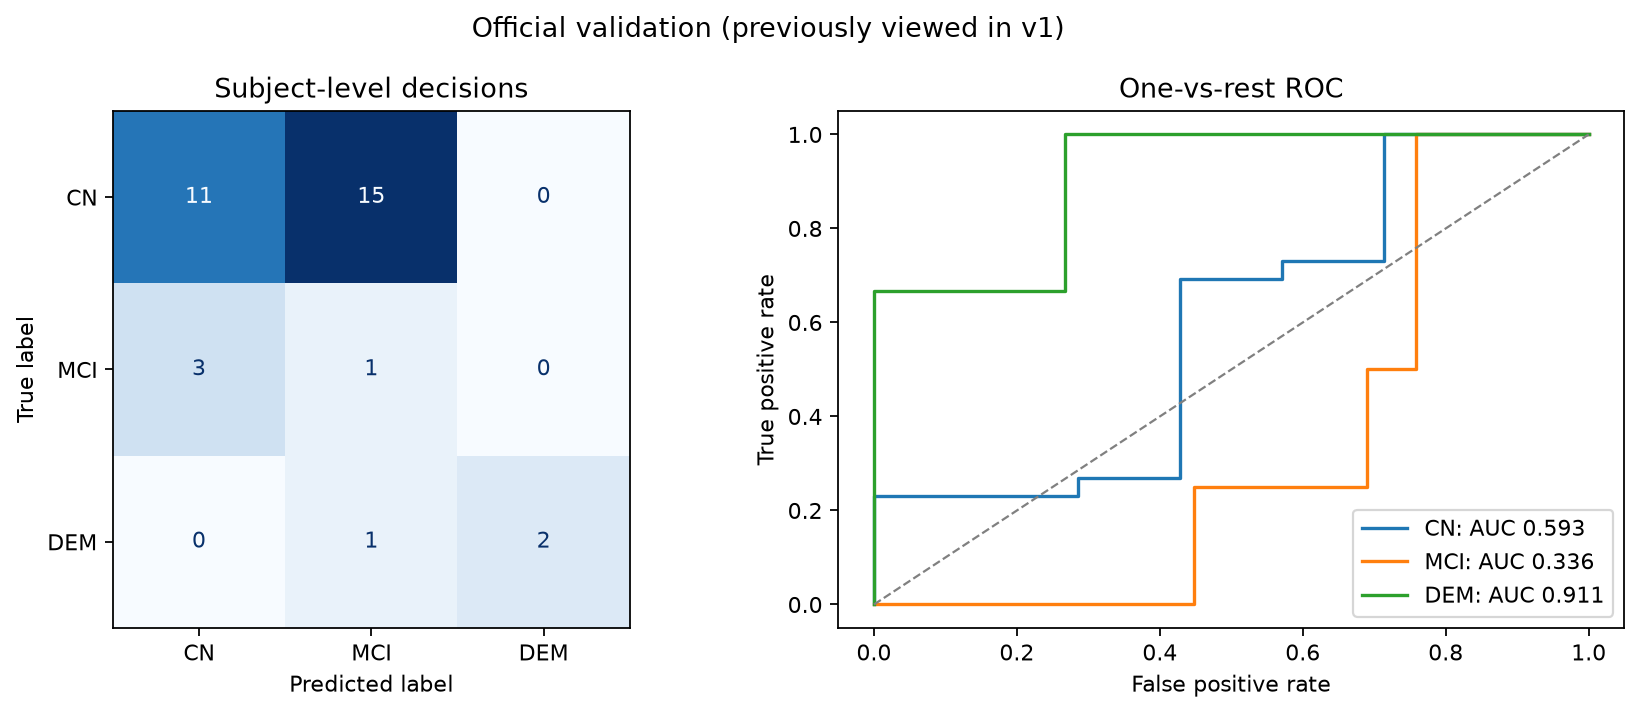

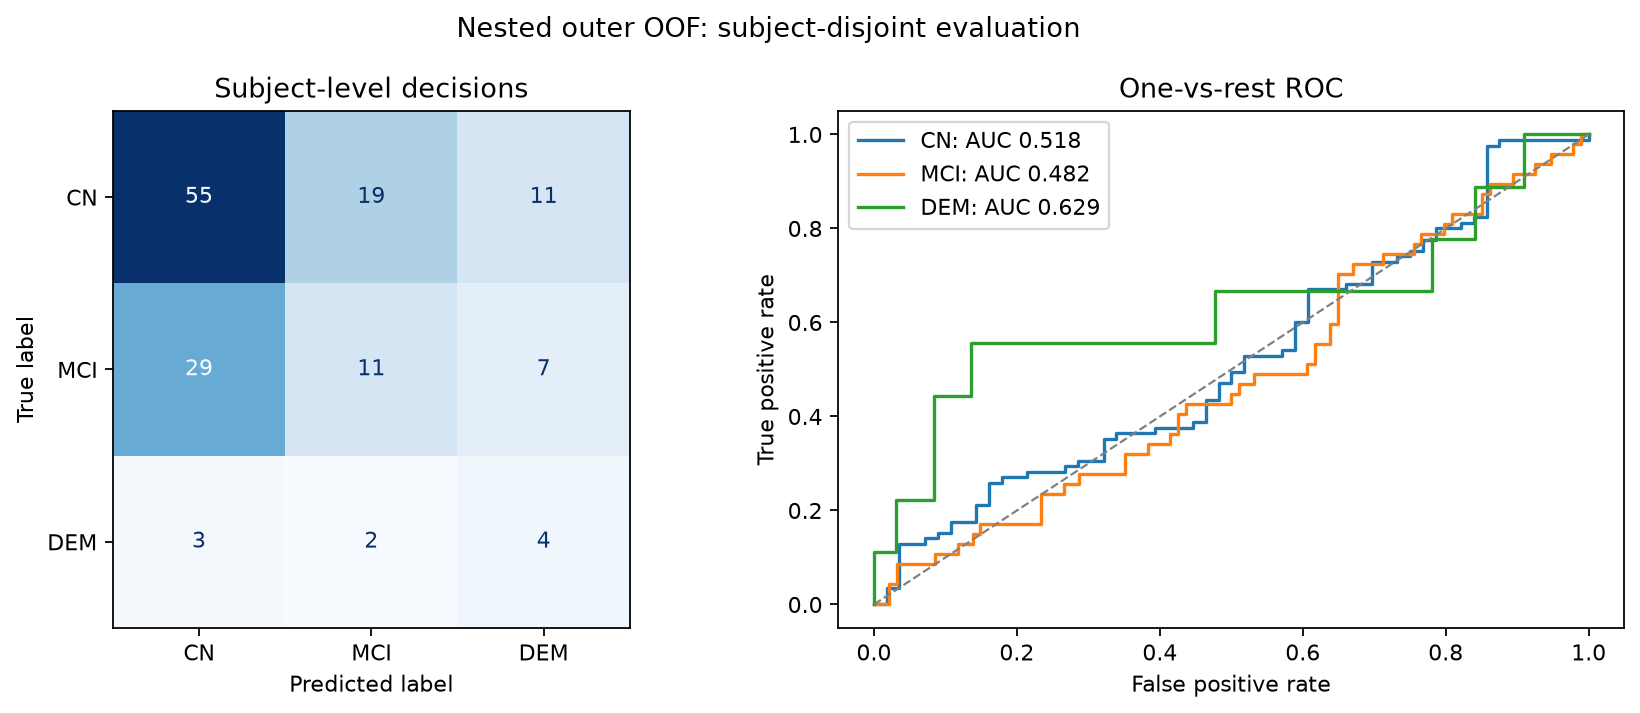

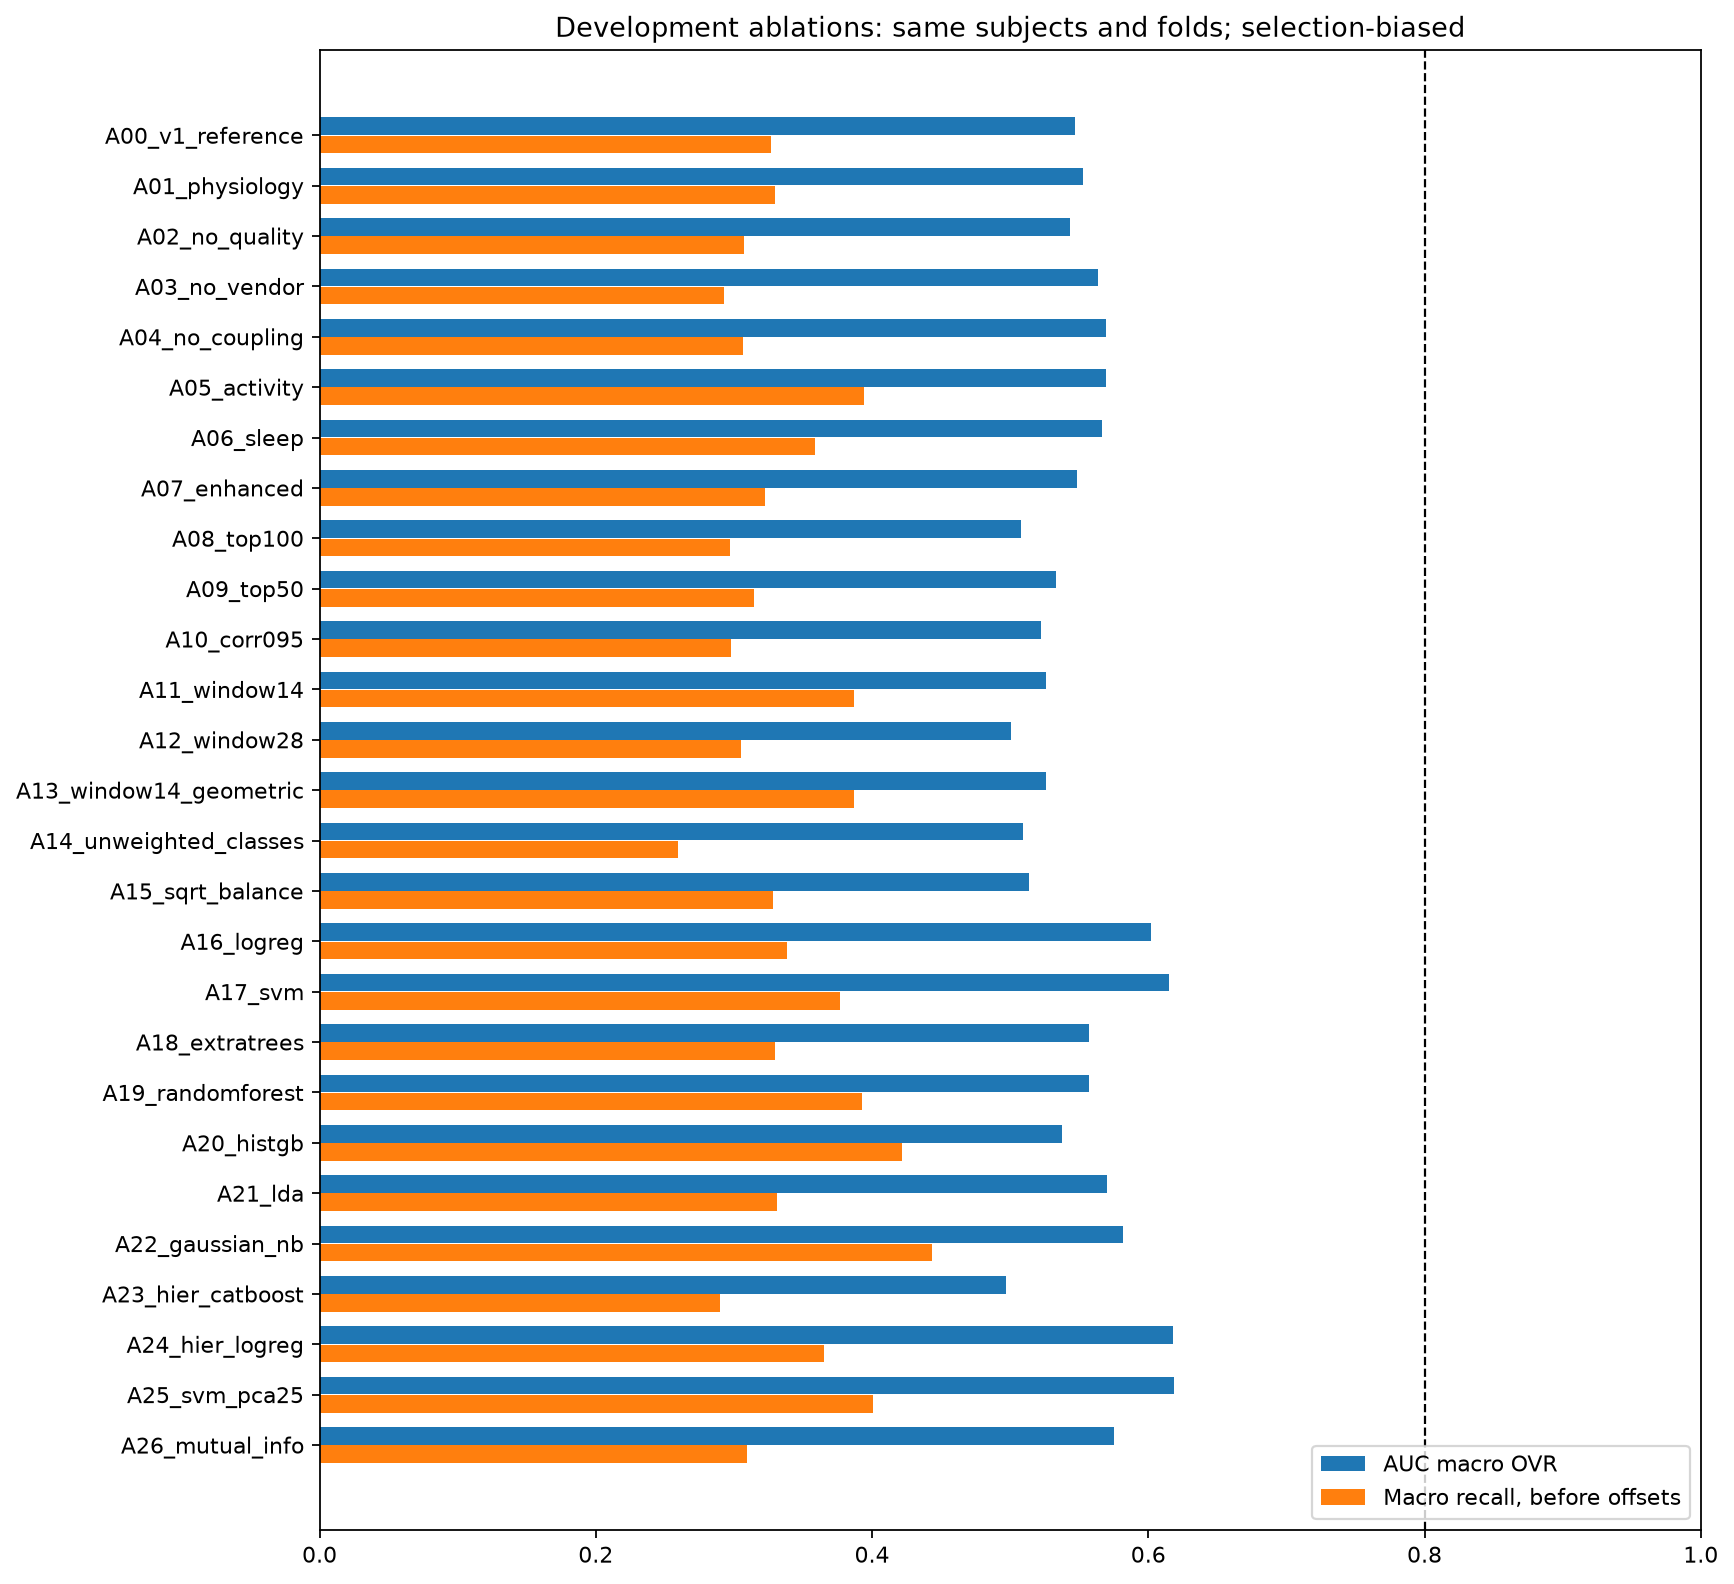

In [6]:
result_dir = Path(CFG.output_dir)
summary_path = result_dir / 'summary.json'
if not summary_path.exists():
    print('학습이 아직 완료되지 않았습니다. v2 성능 수치는 없습니다.')
else:
    summary = json.loads(summary_path.read_text())
    display(Markdown((result_dir / 'RESULTS.md').read_text()))
    display(pd.read_csv(result_dir / 'validation_bootstrap_ci.csv'))
    for filename in ['validation_evaluation.png', 'nested_evaluation.png', 'development_ablation.png']:
        image_path = result_dir / filename
        if image_path.exists():
            display(Image(filename=str(image_path)))

In [7]:
ablation_result = result_dir / 'development' / 'ablation.csv'
if ablation_result.exists():
    comparison = pd.read_csv(ablation_result)
    display(comparison[['name', 'parent', 'raw_roc_auc_macro_ovr', 'raw_macro_recall',
                        'tuned_macro_recall', 'delta_raw_roc_auc_macro_ovr_vs_parent',
                        'delta_raw_macro_recall_vs_parent']])
else:
    print('현재 ablation 계획만 준비되어 있습니다. 재학습 결과는 아직 없습니다.')

,name,parent,raw_roc_auc_macro_ovr,raw_macro_recall,tuned_macro_recall,delta_raw_roc_auc_macro_ovr_vs_parent,delta_raw_macro_recall_vs_parent
0,A00_v1_reference,NaN,0.546682,0.326649,0.508497,NaN,NaN
1,A01_physiology,A00_v1_reference,0.552722,0.329820,0.512418,0.006039,0.003171
2,A02_no_quality,A00_v1_reference,0.543202,0.307041,0.512418,-0.003480,-0.019608
3,A03_no_vendor,A00_v1_reference,0.563391,0.292783,0.508497,0.016708,-0.033866
4,A04_no_coupling,A00_v1_reference,0.569330,0.306216,0.520929,0.022648,-0.020433
5,A05_activity,A00_v1_reference,0.569672,0.394475,0.541288,0.022989,0.067826
6,A06_sleep,A00_v1_reference,0.566809,0.359014,0.440087,0.020127,0.032365
7,A07_enhanced,A00_v1_reference,0.548191,0.322727,0.466787,0.001509,-0.003922
8,A08_top100,A07_enhanced,0.507894,0.297019,0.475381,-0.040298,-0.025708
9,A09_top50,A07_enhanced,0.533246,0.314208,0.454031,-0.014945,-0.008520


## 9. 저장 모델로 새 피험자 예측

동일한 활동·수면 CSV 스키마가 필요하며 MMSE나 진단 라벨 파일은 필요하지 않습니다. 특징 코드/설정과 패키지 버전을 함께 보존하세요. 저장 모델은 이 프로젝트가 생성한 신뢰할 수 있는 로컬 파일만 로드하세요.

In [8]:
def predict_new_subjects(activity_csv, sleep_csv, model_path=None):
    import joblib
    model_path = Path(model_path) if model_path else Path(CFG.output_dir) / 'candidate_model.joblib'
    if not model_path.exists():
        raise FileNotFoundError('학습 완료 후 생성된 모델 경로를 지정하세요.')
    bundle = joblib.load(model_path)
    return bundle.predict_csv(activity_csv, sleep_csv)

# 실제 새 피험자 파일을 준비한 뒤 호출:
# predictions = predict_new_subjects('/path/new_activity.csv', '/path/new_sleep.csv')
# display(predictions.reset_index(drop=True))

## 공식 문서

- [scikit-learn nested/non-nested CV](https://sklearn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html): 모델 선택과 평가 분리.
- [그룹과 층화를 결합하는 CV](https://sklearn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html): 피험자 분리 원칙. 이 코드는 유일한 피험자 테이블을 먼저 층화합니다.
- [CatBoost 파라미터](https://catboost.ai/docs/en/references/training-parameters/common): boosting 및 가중치 설정.

**데이터 처리와 학습 없는 검증은 실제 수행했지만, 이 노트북의 분류기 학습 셀은 제작 시 실행하지 않았습니다.** 성공 수치를 미리 채우지 않습니다.